# Titanic Survival Prediction — Supervised Learning Mini-Project

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 3.0.5
NumPy: 2.5.1
Scikit-learn: 1.9.0


## Step 1: Dataset & Task
Use the Titanic `tested.csv` dataset. The target `Survived` is binary (0/1), so this is a classification task.

In [13]:
df = pd.read_csv("tested.csv")

print(df.shape)
df.head()

(418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Step 2: EDA & Preprocessing
Check distributions, missing values, and class balance, then clean, encode, and scale the features (fit on train only).

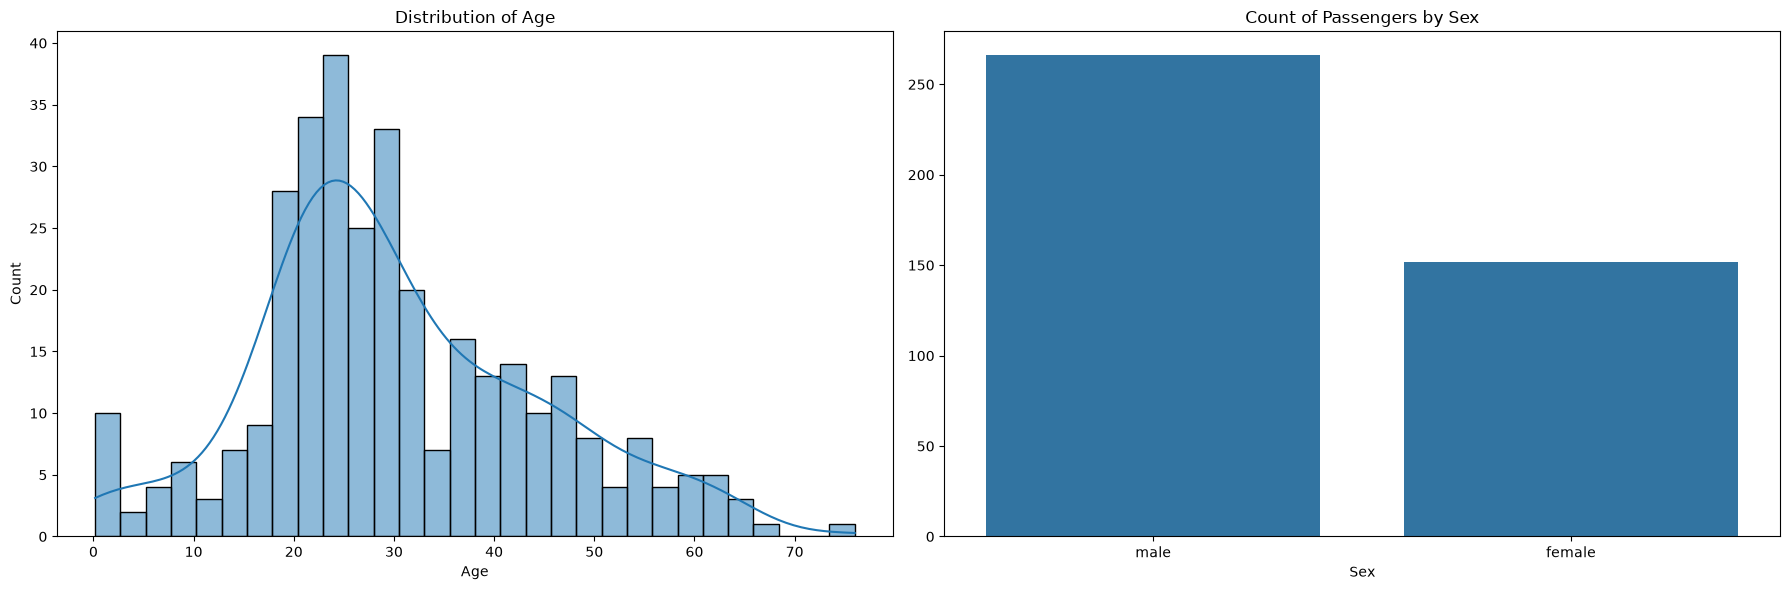

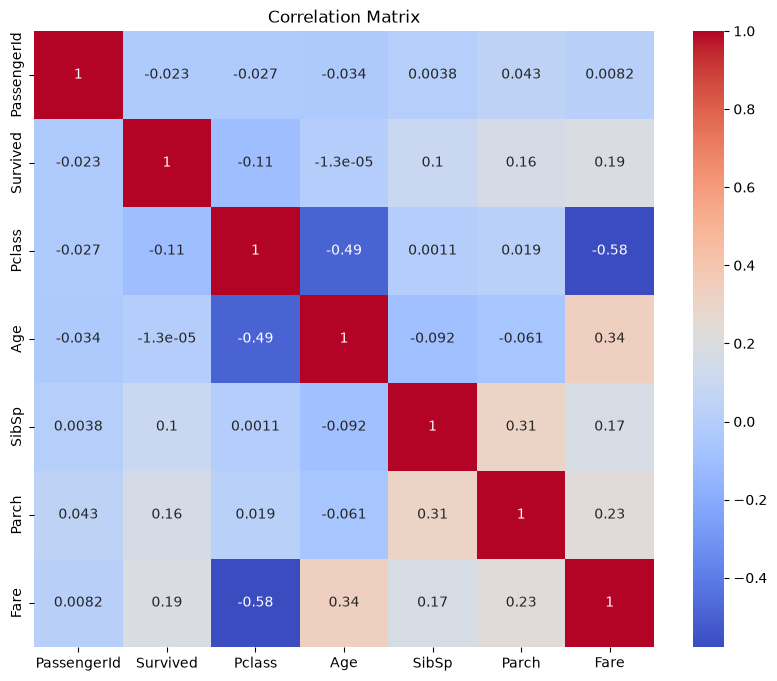

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['Age'], bins=30, kde=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.barplot(x=df['Sex'].value_counts().index,
            y=df['Sex'].value_counts().values,
            ax=axes[1])
axes[1].set_title('Count of Passengers by Sex')

plt.tight_layout()
plt.show()

correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [15]:
print(df.isnull().sum())
print(df[["Age", "Cabin", "Fare"]].dtypes)

survival_counts = df['Survived'].value_counts()
print("Survived (1):", survival_counts[1], "passengers  ", survival_counts[1]/len(df)*100, "%")
print("Died (0):", survival_counts[0], "passengers  ", survival_counts[0]/len(df)*100, "%")
print("Overall Survival Rate:", df['Survived'].mean()*100, "%")

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
Age      float64
Cabin        str
Fare     float64
dtype: object
Survived (1): 152 passengers   36.36363636363637 %
Died (0): 266 passengers   63.63636363636363 %
Overall Survival Rate: 36.36363636363637 %


In [16]:
df.fillna({'Age': df['Age'].median(), 'Fare': df['Fare'].median()}, inplace=True)
df.fillna({'Cabin': 'no cabin'}, inplace=True)
df.drop("Name", axis=1, inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

numeric_features = ["Age", "Fare", "SibSp", "Parch", "Pclass"]

X = df.drop(["Survived", "PassengerId", "Ticket", "Cabin"], axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train[numeric_features])
X_test = scaler.transform(X_test[numeric_features])

## Step 3: Train Models & Evaluate Against a Baseline
train a dummy baseline plus five classifiers, then compare accuracy, precision, recall, and F1 for each.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print("Logistic Regression Train Accuracy:", log_reg.score(X_train, y_train))
print("Logistic Regression Test Accuracy:", log_reg.score(X_test, y_test))

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
print("\nDecision Tree Test Accuracy:", dt.score(X_test, y_test))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("\nRandom Forest Test Accuracy:", rf.score(X_test, y_test))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("\nK-Nearest Neighbors Test Accuracy:", knn.score(X_test, y_test))

svc = SVC(kernel="linear", random_state=42)
svc.fit(X_train, y_train)
print("\nSVM Test Accuracy:", svc.score(X_test, y_test))

Logistic Regression Train Accuracy: 0.6497005988023952
Logistic Regression Test Accuracy: 0.6190476190476191

Decision Tree Test Accuracy: 0.6190476190476191

Random Forest Test Accuracy: 0.5714285714285714

K-Nearest Neighbors Test Accuracy: 0.6785714285714286

SVM Test Accuracy: 0.6071428571428571


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_preds = baseline.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, baseline_preds))
print("Baseline Precision:", precision_score(y_test, baseline_preds, zero_division=0))
print("Baseline Recall:", recall_score(y_test, baseline_preds, zero_division=0))
print("Baseline F1:", f1_score(y_test, baseline_preds, zero_division=0))

models = {
    "Baseline": baseline,
    "Logistic Regression": log_reg,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "SVM": svc
}

results = []
for name, model in models.items():
    preds = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-score": f1_score(y_test, preds, zero_division=0)
    })

results_table = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
print(results_table)

baseline_f1 = results_table.loc[results_table["Model"] == "Baseline", "F1-score"].values[0]
best_row = results_table.iloc[0]
print("Best model:", best_row["Model"])
print("Best F1:", best_row["F1-score"])
print("Baseline F1:", baseline_f1)
print("Improvement:", best_row["F1-score"] - baseline_f1)

Baseline Accuracy: 0.5952380952380952
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0
                 Model  Accuracy  Precision    Recall  F1-score
4                  KNN  0.678571   0.684211  0.382353  0.490566
2        Decision Tree  0.619048   0.541667  0.382353  0.448276
3        Random Forest  0.571429   0.450000  0.264706  0.333333
1  Logistic Regression  0.619048   0.666667  0.117647  0.200000
5                  SVM  0.607143   0.600000  0.088235  0.153846
0             Baseline  0.595238   0.000000  0.000000  0.000000
Best model: KNN
Best F1: 0.49056603773584906
Baseline F1: 0.0
Improvement: 0.49056603773584906


**Result:** KNN was the best-performing model, with an F1-score of 0.491 versus 0.000 for the baseline — an improvement of +0.491. It had the best balance of precision (0.684) and recall (0.382) among all models tested. Logistic Regression and SVM had higher precision but very low recall, meaning they rarely predicted survival even when correct, making KNN the more useful model overall despite Random Forest normally being expected to perform best on this type of data.

## Step 4: Select & Justify the Best Model
pick the model with the highest F1-score, then inspect its full classification report and confusion matrix.

                precision    recall  f1-score   support

Didn't Survive       0.68      0.88      0.77        50
      Survived       0.68      0.38      0.49        34

      accuracy                           0.68        84
     macro avg       0.68      0.63      0.63        84
  weighted avg       0.68      0.68      0.65        84

ROC-AUC: 0.6720588235294117


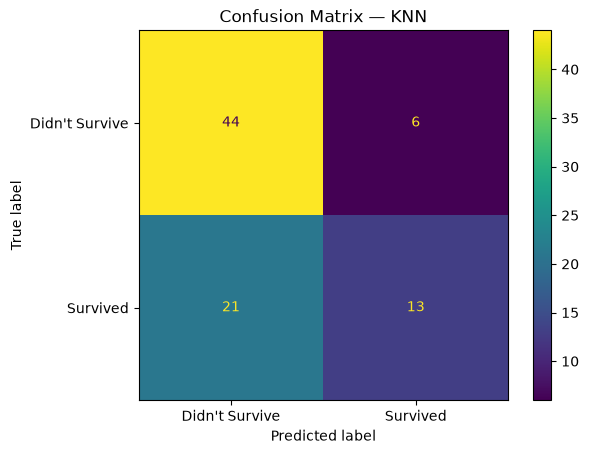

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score

best_model = models[best_row["Model"]]
best_preds = best_model.predict(X_test)

print(classification_report(y_test, best_preds, target_names=["Didn't Survive", "Survived"]))

y_proba = best_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, best_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Didn't Survive", "Survived"]).plot()
plt.title(f"Confusion Matrix — {best_row['Model']}")
plt.show()